# Análise de resultados dos modelos e avaliação do CPOD

In [52]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(stringr)
library(tidyr)
library(purrr)
library(scales)
library(MASS)     # para fitdistr e binomial negativa
library(fitdistrplus)  # para ajustar e comparar distribuições


### Funções

In [53]:
# Verifica alinhamento por cd_exame
check_alignment <- function(gabarito, predicao) {
  if (!all(gabarito$cd_exame == predicao$cd_exame)) {
    stop("As tabelas não estão alinhadas pelo cd_exame.")
  }
}

In [54]:
# Seleciona colunas por prefixo (ex.: "ausente", "carie", "obturado")
select_tooth_cols <- function(data, prefix) {
  patt <- paste0("^", prefix, "_\\d{2}$")
  grep(patt, names(data), value = TRUE)
}

In [55]:
# Converte qualquer coluna para inteiro de forma segura, preservando contagens
to_int <- function(x) {
  # tenta converter para numérico
  if (is.numeric(x)) return(as.integer(round(x)))
  
  # trata casos com strings numéricas, vírgulas, etc.
  lx <- trimws(tolower(as.character(x)))
  lx <- str_replace_all(lx, ",", ".")
  
  # converte para número; valores não numéricos viram NA
  as.integer(suppressWarnings(as.numeric(lx)))
}

In [56]:
# Calcula métricas por dente para um prefixo, aceitando contagens e binarizando para métricas
metrics_by_tooth <- function(gabarito, predicao, prefix, binarize_threshold = 0L) {
  check_alignment(gabarito, predicao)

  cols_g <- select_tooth_cols(gabarito, prefix)
  cols_p <- select_tooth_cols(predicao, prefix)
  cols   <- intersect(cols_g, cols_p)
  if (length(cols) == 0) stop(sprintf("Nenhuma coluna encontrada para o prefixo '%s'.", prefix))

  gtmp <- gabarito[cols]
  ptmp <- predicao[cols]
  gtmp[] <- lapply(gtmp, to_int)
  ptmp[] <- lapply(ptmp, to_int)

  # Calcula as métricas para uma coluna
  calc_one <- function(col) {
      gt <- gtmp[[col]]
      pr <- ptmp[[col]]
      ok <- !(is.na(gt) | is.na(pr))
      gt <- gt[ok]; pr <- pr[ok]

      # binarização: presença se contagem > binarize_threshold
      gt_bin <- as.integer(gt > binarize_threshold)
      pr_bin <- as.integer(pr > binarize_threshold)

      tp <- sum(pr_bin == 1 & gt_bin == 1)
      tn <- sum(pr_bin == 0 & gt_bin == 0)
      fp <- sum(pr_bin == 1 & gt_bin == 0)
      fn <- sum(pr_bin == 0 & gt_bin == 1)
      n  <- length(gt_bin)

      precision <- if ((tp + fp) == 0) NA_real_ else tp / (tp + fp)
      recall    <- if ((tp + fn) == 0) NA_real_ else tp / (tp + fn)
      f1        <- if (is.na(precision) || is.na(recall) || (precision + recall) == 0) NA_real_ else 2 * precision * recall / (precision + recall)
      accuracy  <- (tp + tn) / n

      # prevalência verdadeira binária e médias de contagem (útil para inspeção)
      prevalence_gt   <- mean(gt_bin == 1)
      mean_count_gt   <- mean(gt, na.rm = TRUE)
      mean_count_pred <- mean(pr, na.rm = TRUE)

      tibble(
        target = prefix,
        coluna = col,
        dente  = as.integer(stringr::str_extract(col, "\\d{2}")),
        n, tp, fp, tn, fn,
        precision, recall, f1, accuracy,
        prevalence_gt, mean_count_gt, mean_count_pred
      )
    }

  purrr::map_dfr(cols, calc_one) %>% arrange(dente, coluna)
}

In [57]:
# Função para gerar gráfico por dente (F1 ou acurácia)
plot_metric_by_tooth <- function(resultado_por_dente, metric = c("f1", "accuracy"),
                                 title = NULL, color = "steelblue") {
  
  # Verifica se a métrica existe na tabela
  metric <- match.arg(metric)
  if (!metric %in% names(resultado_por_dente)) {
    stop(paste("Métrica", metric, "não encontrada no dataframe."))
  }
  
  # Ordem odontológica FDI
  ordem_fdi <- c(18,17,16,15,14,13,12,11,
                 21,22,23,24,25,26,27,28,
                 38,37,36,35,34,33,32,31,
                 41,42,43,44,45,46,47,48)
  
  # Prepara os dados
  resultado_plot <- resultado_por_dente %>%
    filter(dente %in% ordem_fdi) %>%
    mutate(dente = factor(dente, levels = ordem_fdi))
  
  # Define título padrão se não for informado
  if (is.null(title)) {
    title <- paste0(toupper(metric), " by tooth (FDI numbering)")
  }
  
  # Gera o gráfico
  ggplot(resultado_plot, aes(x = dente, y = .data[[metric]])) +
    geom_col(fill = color) +
    geom_text(
      aes(label = round(.data[[metric]], 2)),
      vjust = -0.3,
      size = 3.2
    ) +
    expand_limits(y = max(resultado_plot[[metric]], na.rm = TRUE) * 1.1) +
    labs(
      title = title,
      x = "Tooth (FDI numbering)",
      y = metric
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1)
    )
}

In [58]:
# Função para calcular agregados macro e micro a partir da tabela por dente
aggregate_macro_micro <- function(resultado_por_dente) {
  
  # Agregado macro: média simples das métricas entre os dentes
  macro <- resultado_por_dente %>%
    summarise(
      precision = mean(precision, na.rm = TRUE),
      recall    = mean(recall,    na.rm = TRUE),
      f1        = mean(f1,        na.rm = TRUE),
      accuracy  = mean(accuracy,  na.rm = TRUE),
      description = "Average of metrics across all teeth (each tooth has equal weight)"
    ) %>%
    mutate(agg = "macro", .before = 1)
  
  # Agregado micro: todas as observações juntas (ponderadas pelo número de casos)
  micro_tp <- sum(resultado_por_dente$tp)
  micro_fp <- sum(resultado_por_dente$fp)
  micro_tn <- sum(resultado_por_dente$tn)
  micro_fn <- sum(resultado_por_dente$fn)
  
  micro_precision <- if ((micro_tp + micro_fp) == 0) NA_real_ else micro_tp / (micro_tp + micro_fp)
  micro_recall    <- if ((micro_tp + micro_fn) == 0) NA_real_ else micro_tp / (micro_tp + micro_fn)
  micro_f1        <- if (is.na(micro_precision) || is.na(micro_recall) || (micro_precision + micro_recall) == 0) NA_real_ else 2 * micro_precision * micro_recall / (micro_precision + micro_recall)
  micro_accuracy  <- (micro_tp + micro_tn) / (micro_tp + micro_fp + micro_tn + micro_fn)
  
  micro <- tibble(
    agg = "micro",
    precision = micro_precision,
    recall    = micro_recall,
    f1        = micro_f1,
    accuracy  = micro_accuracy,
    description = "Global metrics considering all teeth together (weighted by number of samples)"
  )
  
  # Combina os resultados
  resumo_global <- bind_rows(macro, micro)
  
  print("Resumo global (macro e micro):")
  print(resumo_global, n = Inf, width = Inf)
  
  return(resumo_global)
}

In [59]:
# Calcula, por exame, a contagem do alvo (prefixo_XX) no gabarito e na predição
compute_counts_by_exam <- function(gabarito, predicao, prefix) {
  stopifnot(all(gabarito$cd_exame == predicao$cd_exame))
  cols <- intersect(names(gabarito), names(predicao))
  cols_target <- grep(paste0("^", prefix, "_\\d{2}$"), cols, value = TRUE)
  if (length(cols_target) == 0) stop(sprintf("Nenhuma coluna encontrada para o prefixo '%s'.", prefix))

  gabarito[cols_target] <- lapply(gabarito[cols_target], as.integer)
  predicao[cols_target] <- lapply(predicao[cols_target], as.integer)

  tibble(
    cd_exame   = gabarito$cd_exame,
    count_gt   = rowSums(gabarito[cols_target], na.rm = TRUE),
    count_pred = rowSums(predicao[cols_target], na.rm = TRUE),
    prefix     = prefix
  ) %>%
    mutate(
      diff          = count_pred - count_gt,
      abs_diff      = abs(diff),
      correct_count = as.integer(count_pred == count_gt)
    )
}

In [60]:
# Sumariza métricas globais a partir da tabela de contagens por exame
summarize_count_metrics <- function(contagens) {
  contagens %>%
    summarise(
      prefix           = first(prefix),
      n_exames         = n(),
      exact_match_rate = mean(correct_count),
      mae              = mean(abs_diff),
      rmse             = sqrt(mean(diff^2)),
      bias             = mean(diff)
    )
}


In [61]:
# (Opcional) Gráfico scatter count_pred vs count_gt com diagonal y = x
plot_counts_scatter <- function(contagens, title = NULL) {
  if (is.null(title)) title <- paste0("Predicted vs True count (", first(contagens$prefix), ")")
  ggplot(contagens, aes(x = count_gt, y = count_pred)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed") +
    coord_equal() +
    expand_limits(x = 0, y = 0) +
    labs(title = title, x = "True count", y = "Predicted count") +
    theme_minimal(base_size = 13)
}

In [62]:
# Gera tabela de contingência + heatmap
contingency_table_counts <- function(contagens, normalize = FALSE) {
  
  # Cria a tabela de contingência
  tab <- contagens %>%
    count(count_gt, count_pred, name = "freq") %>%
    arrange(count_gt, count_pred)
  
  # Normaliza (opcional: mostra porcentagens em vez de contagem bruta)
  if (normalize) {
    total <- sum(tab$freq)
    tab <- tab %>%
      mutate(freq = freq / total,
             label = paste0(round(100 * freq, 1), "%"))
  } else {
    tab <- tab %>%
      mutate(label = as.character(freq))
  }
  
  # Gera o heatmap
  ggplot(tab, aes(x = count_gt, y = count_pred, fill = freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = label), size = 3.5) +
    scale_fill_gradient(low = "white", high = "steelblue",
                        name = if (normalize) "Proportion" else "Frequency",
                        labels = if (normalize) percent_format(accuracy = 1) else NULL) +
    coord_equal() +
    labs(
      title = paste0("Heatmap of predicted vs true counts (", first(contagens$prefix), ")"),
      x = "True count (gabarito)",
      y = "Predicted count (modelo)"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      panel.grid = element_blank(),
      axis.text = element_text(size = 11)
    )
}


In [63]:
# Calcula CPOD (Cariado, Perdido, Obturado) por exame
compute_cpod <- function(data) {
  
  # Identifica colunas para cada categoria
  cols_ausentes  <- grep("^ausente_\\d{2}$", names(data), value = TRUE)
  cols_cariados  <- grep("^carie_\\d{2}$",   names(data), value = TRUE)
  cols_obturados <- grep("^obturado_\\d{2}$", names(data), value = TRUE)
  
  # Garante que existam todas as colunas esperadas
  if (length(cols_ausentes) == 0 | length(cols_cariados) == 0 | length(cols_obturados) == 0) {
    stop("Faltam colunas de um ou mais componentes: ausente, carie ou obturado.")
  }
  
  # Converte para inteiro (caso estejam como texto)
  data[cols_ausentes]  <- lapply(data[cols_ausentes],  as.integer)
  data[cols_cariados]  <- lapply(data[cols_cariados],  as.integer)
  data[cols_obturados] <- lapply(data[cols_obturados], as.integer)
  
  # Calcula as somas por exame
  cpod <- tibble(
    cd_exame  = data$cd_exame,
    ausentes  = rowSums(data[cols_ausentes],  na.rm = TRUE),
    cariados  = rowSums(data[cols_cariados],  na.rm = TRUE),
    obturados = rowSums(data[cols_obturados], na.rm = TRUE)
  ) %>%
    mutate(cpod_total = ausentes + cariados + obturados)
  
  return(cpod)
}

In [64]:
compute_cpod_binaria <- function(data) {
  
  # Identifica colunas de cada categoria
  cols_ausentes  <- grep("^ausente_\\d{2}$", names(data), value = TRUE)
  cols_cariados  <- grep("^carie_\\d{2}$",   names(data), value = TRUE)
  cols_obturados <- grep("^obturado_\\d{2}$", names(data), value = TRUE)
  
  # Garante que todas existam
  if (length(cols_ausentes) == 0 | length(cols_cariados) == 0 | length(cols_obturados) == 0) {
    stop("Faltam colunas de um ou mais componentes: ausente, carie ou obturado.")
  }
  
  # Converte para inteiro e binariza: se o valor for >0, vira 1
  data[cols_ausentes]  <- lapply(data[cols_ausentes],  function(x) as.integer(as.numeric(x) > 0))
  data[cols_cariados]  <- lapply(data[cols_cariados],  function(x) as.integer(as.numeric(x) > 0))
  data[cols_obturados] <- lapply(data[cols_obturados], function(x) as.integer(as.numeric(x) > 0))
  
  # Soma por exame (cada dente conta no máximo 1)
  cpod <- tibble(
    cd_exame  = data$cd_exame,
    ausentes  = rowSums(data[cols_ausentes],  na.rm = TRUE),
    cariados  = rowSums(data[cols_cariados],  na.rm = TRUE),
    obturados = rowSums(data[cols_obturados], na.rm = TRUE)
  ) %>%
    mutate(cpod_total = ausentes + cariados + obturados)
  
  return(cpod)
}

In [65]:
# Função geral para calcular e visualizar a distribuição do CPOD
analyze_cpod <- function(data, compute_fun = compute_cpod, titulo = "Prediction") {
  
  # Calcula CPOD usando a função escolhida
  cpod_df <- compute_fun(data)
  
  # Exibe preview e resumo numérico
  print(head(cpod_df))
  print(summary(cpod_df$cpod_total))
  
  # Histograma da distribuição
  p_hist <- ggplot(cpod_df, aes(x = cpod_total)) +
    geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
    labs(
      title = paste0("Distribution of CPOD total (", tolower(titulo), ")"),
      x = "CPOD total (number of affected teeth)",
      y = "Number of patients"
    ) +
    theme_minimal(base_size = 13)
  print(p_hist)
  
  # Distribuição acumulada (CDF)
  p_cdf <- ggplot(cpod_df, aes(x = cpod_total)) +
    stat_ecdf(geom = "step", color = "darkred", linewidth = 1) +
    labs(
      title = paste0("Cumulative distribution of CPOD total (", tolower(titulo), ")"),
      x = "CPOD total",
      y = "Cumulative proportion"
    ) +
    theme_minimal(base_size = 13)
  print(p_cdf)
  
  # Boxplot
  p_box <- ggplot(cpod_df, aes(y = cpod_total)) +
    geom_boxplot(fill = "orange", alpha = 0.7) +
    labs(
      title = paste0("Boxplot of CPOD total (", tolower(titulo), ")"),
      y = "CPOD total"
    ) +
    theme_minimal(base_size = 13)
  print(p_box)
  
  # Retorna o data frame calculado (caso queira usar depois)
  return(cpod_df)
}


In [66]:
# Testa a distribuição de CPOD total (Normal, Poisson, Binomial Negativa)
test_cpod_distribution <- function(cpod_df, titulo = "CPOD total") {
  
  x <- cpod_df$cpod_total
  x <- x[!is.na(x)]
  
  # Teste de normalidade (Shapiro-Wilk)
  x_test <- if (length(x) > 5000) sample(x, 5000) else x
  normal_test <- shapiro.test(x_test)
  
  # Ajuste Poisson
  lambda_hat <- mean(x)
  pois_ll <- sum(dpois(x, lambda_hat, log = TRUE))
  
  # Ajuste Binomial Negativa
  nb_fit <- fitdistrplus::fitdist(x, "nbinom")
  
  # Log-likelihoods e AICs
  normal_ll <- sum(dnorm(x, mean(x), sd(x), log = TRUE))
  nb_ll <- sum(dnbinom(x, mu = nb_fit$estimate["mu"], size = nb_fit$estimate["size"], log = TRUE))
  
  aic_table <- tibble(
    Model = c("Normal", "Poisson", "Negative Binomial"),
    LogLik = c(normal_ll, pois_ll, nb_ll),
    AIC = c(-2 * normal_ll + 2 * 2,
            -2 * pois_ll + 2 * 1,
            -2 * nb_ll + 2 * 2)
  ) %>% arrange(AIC)
  
  print("AIC comparison (lower = better):")
  print(aic_table, width = Inf)
  print(paste("Shapiro-Wilk p-value for normality:", round(normal_test$p.value, 5)))
  
  # Curvas ajustadas
  x_grid <- seq(0, max(x), 1)
  df_fit <- tibble(
    x = x_grid,
    Poisson = dpois(x_grid, lambda_hat),
    NegBin  = dnbinom(x_grid, mu = nb_fit$estimate["mu"], size = nb_fit$estimate["size"]),
    Normal  = dnorm(x_grid, mean(x), sd(x))
  ) %>%
    pivot_longer(cols = -x, names_to = "Distribuição", values_to = "Densidade")
  
  # Plot comparativo das distribuições ajustadas
  print(
    ggplot() +
      geom_histogram(aes(x = x, y = after_stat(density)), binwidth = 1,
                     fill = "gray85", color = "white", alpha = 0.7) +
      geom_line(data = df_fit, aes(x = x, y = Densidade, color = Distribuição), linewidth = 1.2) +
      scale_color_manual(values = c("Poisson" = "blue", "NegBin" = "red", "Normal" = "darkgreen")) +
      labs(
        title = paste("Fitted distributions for", titulo),
        x = "CPOD total", y = "Density"
      ) +
      theme_minimal(base_size = 13)
  )
  
  return(list(
    normal_test = normal_test,
    poisson_lambda = lambda_hat,
    negbin_fit = nb_fit,
    aic_comparison = aic_table
  ))
}

### Arquivos de entrada

In [67]:

# Definir caminhos
gabarito_path <- "/home/aninha/Desktop/Doutorado/Dados/tabela_cpod_larga_gabarito.csv"
predicao_path <- "/home/aninha/Desktop/Doutorado/Dados/tabela_cpod_larga_predicao.csv"

# Ler os arquivos
gabarito <- read_csv(gabarito_path)
predicao <- read_csv(predicao_path)


Rows: 2515 Columns: 100
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): cd_exame, origem, sexo
dbl (97): idade, ausente_11, ausente_12, ausente_13, ausente_14, ausente_15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 2515 Columns: 100
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): cd_exame, origem, sexo
dbl (97): idade, ausente_11, ausente_12, ausente_13, ausente_14, ausente_15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [68]:
# Ver primeiras linhas e estrutura
cat("Gabarito:\n")
print(head(gabarito))
cat("\nEstrutura:\n")
print(glimpse(gabarito))

Gabarito:
# A tibble: 6 × 100
  cd_exame   origem     idade sexo   ausente_11 ausente_12 ausente_13 ausente_14
  <chr>      <chr>      <dbl> <chr>       <dbl>      <dbl>      <dbl>      <dbl>
1 alp.026080 Alphaville    24 mascu…          0          0          0          0
2 alp.026233 Alphaville    27 mascu…          0          0          0          0
3 alp.026520 Alphaville    63 femin…          0          0          0          0
4 alp.026854 Alphaville    22 mascu…          0          0          0          0
5 alp.026933 Alphaville    25 mascu…          0          0          0          0
6 alp.027497 Alphaville    42 femin…          1          0          0          1
# ℹ 92 more variables: ausente_15 <dbl>, ausente_16 <dbl>, ausente_17 <dbl>,
#   ausente_18 <dbl>, ausente_21 <dbl>, ausente_22 <dbl>, ausente_23 <dbl>,
#   ausente_24 <dbl>, ausente_25 <dbl>, ausente_26 <dbl>, ausente_27 <dbl>,
#   ausente_28 <dbl>, ausente_31 <dbl>, ausente_32 <dbl>, ausente_33 <dbl>,
#   ausente_34 <d

In [69]:
cat("\n\nPredição:\n")
print(head(predicao))
cat("\nEstrutura:\n")
print(glimpse(predicao))



Predição:
# A tibble: 6 × 100
  cd_exame   origem     idade sexo   ausente_11 ausente_12 ausente_13 ausente_14
  <chr>      <chr>      <dbl> <chr>       <dbl>      <dbl>      <dbl>      <dbl>
1 alp.026233 Alphaville    27 mascu…          0          0          0          0
2 alp.026520 Alphaville    63 femin…          0          0          0          0
3 alp.026933 Alphaville    25 mascu…          0          1          1          0
4 alp.027497 Alphaville    42 femin…          0          0          0          1
5 alp.027806 Alphaville    29 mascu…          0          0          0          1
6 alp.027880 Alphaville    43 femin…          0          0          0          0
# ℹ 92 more variables: ausente_15 <dbl>, ausente_16 <dbl>, ausente_17 <dbl>,
#   ausente_18 <dbl>, ausente_21 <dbl>, ausente_22 <dbl>, ausente_23 <dbl>,
#   ausente_24 <dbl>, ausente_25 <dbl>, ausente_26 <dbl>, ausente_27 <dbl>,
#   ausente_28 <dbl>, ausente_31 <dbl>, ausente_32 <dbl>, ausente_33 <dbl>,
#   ausente_34 

In [70]:
# Ordenar ambas as tabelas em ordem alfabética por cd_exame
gabarito <- gabarito %>%
  arrange(cd_exame)

predicao <- predicao %>%
  arrange(cd_exame)

# Verificar se agora estão na mesma ordem
if (all(gabarito$cd_exame == predicao$cd_exame)) {
  print("As tabelas foram ordenadas e estão na mesma ordem.")
} else {
  print("Ainda há diferenças na ordem ou nos cd_exame.")
  diferentes <- which(gabarito$cd_exame != predicao$cd_exame)
  diff_df <- tibble(
    linha = diferentes,
    cd_exame_gabarito = gabarito$cd_exame[diferentes],
    cd_exame_predicao = predicao$cd_exame[diferentes]
  )
  print(head(diff_df))
}

[1] "As tabelas foram ordenadas e estão na mesma ordem."


### Análise descritiva das amostras

In [71]:
head(gabarito[,1:4])


cd_exame,origem,idade,sexo
<chr>,<chr>,<dbl>,<chr>
alp.026080,Alphaville,24,masculino
alp.026233,Alphaville,27,masculino
alp.026520,Alphaville,63,feminino
alp.026854,Alphaville,22,masculino
alp.026933,Alphaville,25,masculino
alp.027497,Alphaville,42,feminino


In [72]:
table(gabarito[,1:4]==predicao[,1:4]) #Checando se gabarito e predição estão corretas


 TRUE 
10060 

In [73]:
# Resumo estatístico das idades
resumo_idade <- predicao %>%
  summarise(
    n = n(),
    media = mean(idade, na.rm = TRUE),
    mediana = median(idade, na.rm = TRUE),
    desvio_padrao = sd(idade, na.rm = TRUE),
    minimo = min(idade, na.rm = TRUE),
    maximo = max(idade, na.rm = TRUE)
  )
print("Resumo descritivo da variável idade:")
print(resumo_idade)

[1] "Resumo descritivo da variável idade:"
# A tibble: 1 × 6
      n media mediana desvio_padrao minimo maximo
  <int> <dbl>   <dbl>         <dbl>  <dbl>  <dbl>
1  2515  48.2      50          17.4      7     93


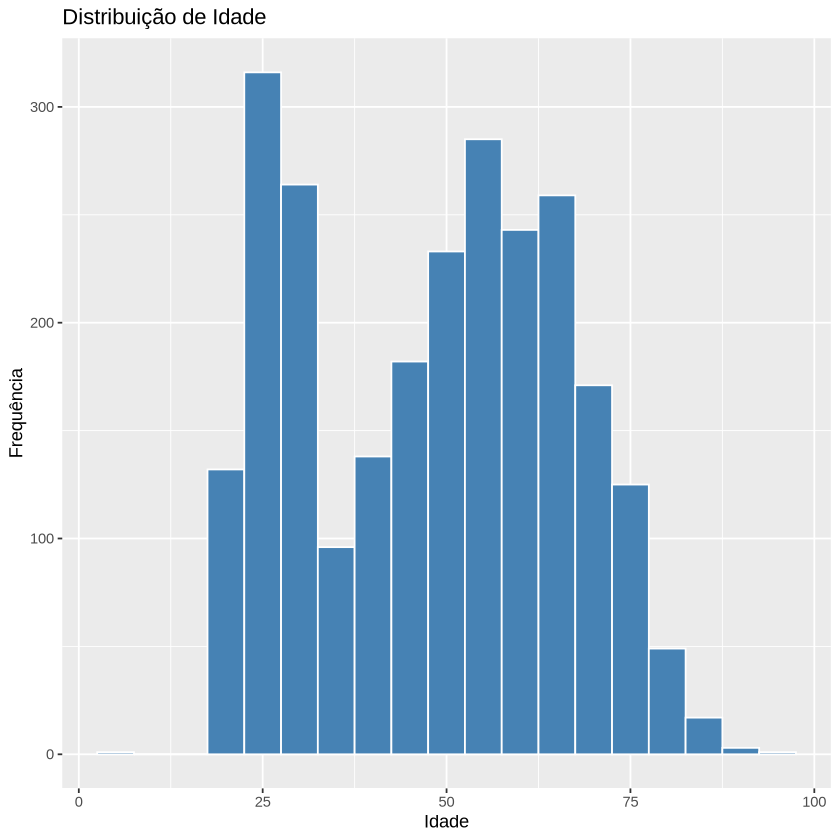

In [74]:
ggplot(predicao, aes(x = idade)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(title = "Distribuição de Idade", x = "Idade", y = "Frequência")

In [75]:
# Distribuição por sexo
resumo_sexo <- predicao %>%
  count(sexo) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição por sexo:")
print(resumo_sexo)

[1] "Distribuição por sexo:"
# A tibble: 2 × 3
  sexo          n proporcao
  <chr>     <int>     <dbl>
1 feminino   1519      60.4
2 masculino   996      39.6


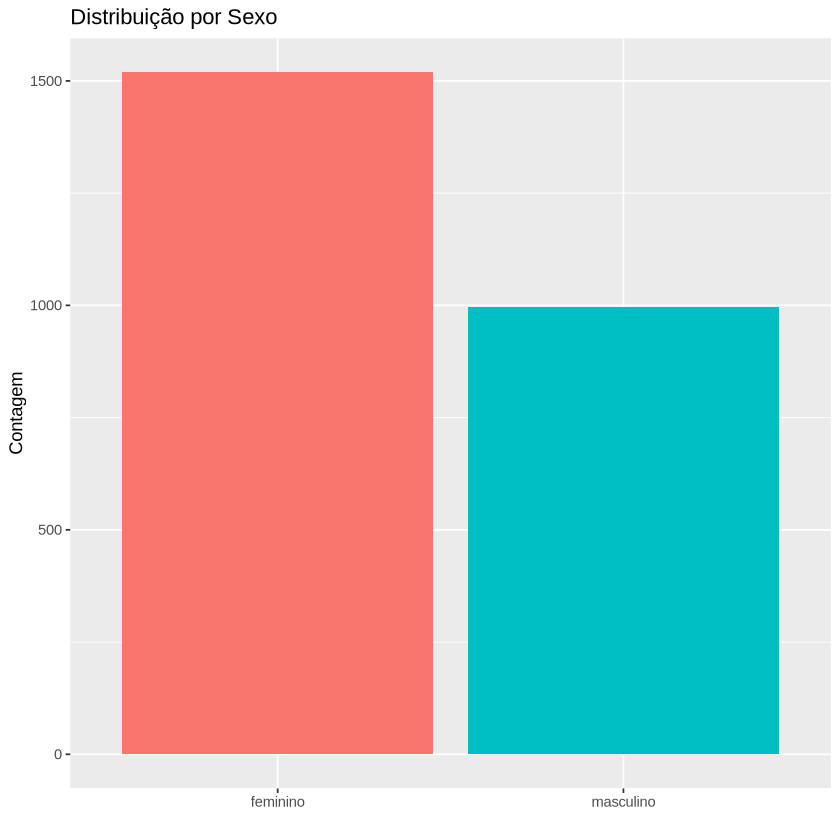

In [76]:
ggplot(predicao, aes(x = sexo, fill = sexo)) +
  geom_bar() +
  labs(title = "Distribuição por Sexo", x = "", y = "Contagem") +
  theme(legend.position = "none")

In [77]:
# Distribuição por origem
resumo_origem <- predicao %>%
  count(origem) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição por origem:")
print(resumo_origem)

[1] "Distribuição por origem:"
# A tibble: 15 × 3
   origem           n proporcao
   <chr>        <int>     <dbl>
 1 Alphaville      55      2.19
 2 Ibirapuera      86      3.42
 3 Ipiranga        72      2.86
 4 Jardins        269     10.7 
 5 Jd. America    190      7.55
 6 Lapa           162      6.44
 7 Mooca           95      3.78
 8 Morumbi         56      2.23
 9 Osasco          55      2.19
10 Penha           66      2.62
11 Santana        446     17.7 
12 Santo Amaro    287     11.4 
13 Tatuape        402     16.0 
14 Tucuruvi         1      0.04
15 Vila Mariana   273     10.8 


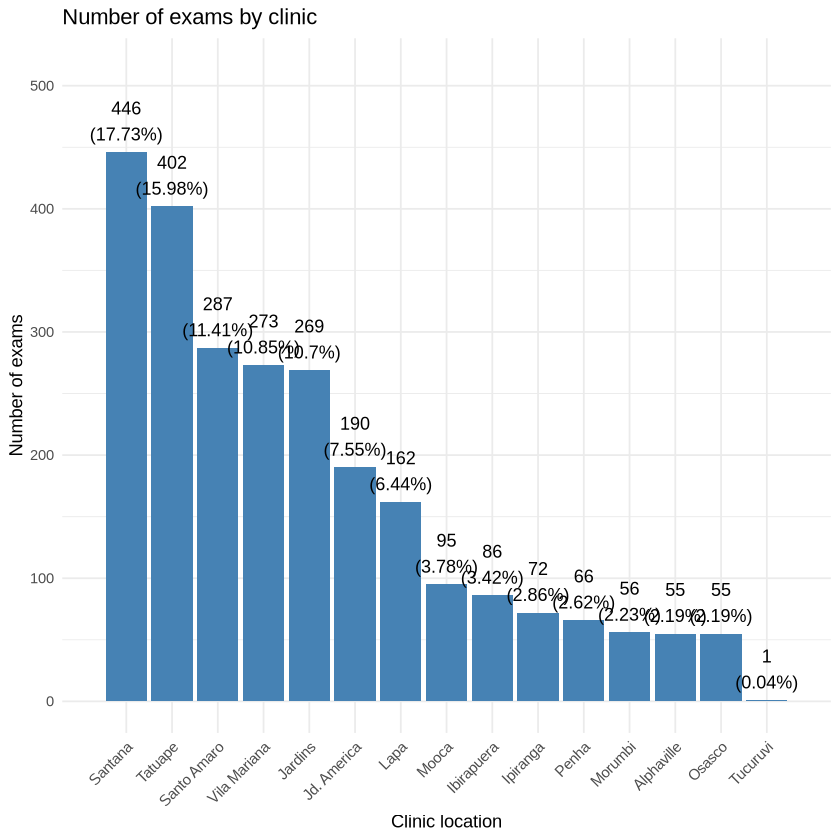

In [78]:
ggplot(resumo_origem, aes(x = reorder(origem, -n), y = n)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = paste0(n, "\n(", proporcao, "%)")),
    vjust = -0.3,
    size = 3.8
  ) +
  expand_limits(y = max(resumo_origem$n) * 1.15) +  # espaço no topo
  scale_x_discrete(expand = expansion(mult = c(0.1, 0.1))) +  # espaçamento lateral entre barras
  labs(
    title = "Number of exams by clinic",
    x = "Clinic location",
    y = "Number of exams"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


In [79]:
# Combinação de origem e sexo
resumo_origem_sexo <- predicao %>%
  count(origem, sexo) %>%
  group_by(origem) %>%
  mutate(proporcao = round(100 * n / sum(n), 2))
print("Distribuição cruzada por origem e sexo:")
print(resumo_origem_sexo, n=Inf)

[1] "Distribuição cruzada por origem e sexo:"
# A tibble: 29 × 4
# Groups:   origem [15]
   origem       sexo          n proporcao
   <chr>        <chr>     <int>     <dbl>
 1 Alphaville   feminino     35      63.6
 2 Alphaville   masculino    20      36.4
 3 Ibirapuera   feminino     60      69.8
 4 Ibirapuera   masculino    26      30.2
 5 Ipiranga     feminino     39      54.2
 6 Ipiranga     masculino    33      45.8
 7 Jardins      feminino    146      54.3
 8 Jardins      masculino   123      45.7
 9 Jd. America  feminino    109      57.4
10 Jd. America  masculino    81      42.6
11 Lapa         feminino     92      56.8
12 Lapa         masculino    70      43.2
13 Mooca        feminino     64      67.4
14 Mooca        masculino    31      32.6
15 Morumbi      feminino     33      58.9
16 Morumbi      masculino    23      41.1
17 Osasco       feminino     37      67.3
18 Osasco       masculino    18      32.7
19 Penha        feminino     45      68.2
20 Penha        masculino    

### Desempenho do modelo de numeração por dente e dentes ausentes

In [80]:
resultado_ausente  <- metrics_by_tooth(gabarito, predicao, prefix = "ausente")
resultado_ausente

target,coluna,dente,n,tp,fp,tn,fn,precision,recall,f1,accuracy,prevalence_gt,mean_count_gt,mean_count_pred
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ausente,ausente_11,11,2515,114,88,2157,156,0.5643564,0.4222222,0.4830508,0.9029821,0.10735586,0.10735586,0.08031809
ausente,ausente_12,12,2515,96,104,2110,205,0.4800000,0.3189369,0.3832335,0.8771372,0.11968191,0.11968191,0.07952286
ausente,ausente_13,13,2515,58,128,2244,85,0.3118280,0.4055944,0.3525836,0.9153082,0.05685885,0.05685885,0.07395626
ausente,ausente_14,14,2515,172,155,1792,396,0.5259939,0.3028169,0.3843575,0.7809145,0.22584493,0.22584493,0.13001988
ausente,ausente_15,15,2515,257,219,1700,339,0.5399160,0.4312081,0.4794776,0.7781312,0.23697813,0.23697813,0.18926441
ausente,ausente_16,16,2515,379,218,1659,259,0.6348409,0.5940439,0.6137652,0.8103380,0.25367793,0.25367793,0.23737575
ausente,ausente_17,17,2515,353,185,1826,151,0.6561338,0.7003968,0.6775432,0.8664016,0.20039761,0.20039761,0.21391650
ausente,ausente_18,18,2515,1402,167,835,111,0.8935628,0.9266358,0.9097988,0.8894632,0.60159046,0.60159046,0.62385686
ausente,ausente_21,21,2515,123,93,2138,161,0.5694444,0.4330986,0.4920000,0.8990060,0.11292247,0.11292247,0.08588469


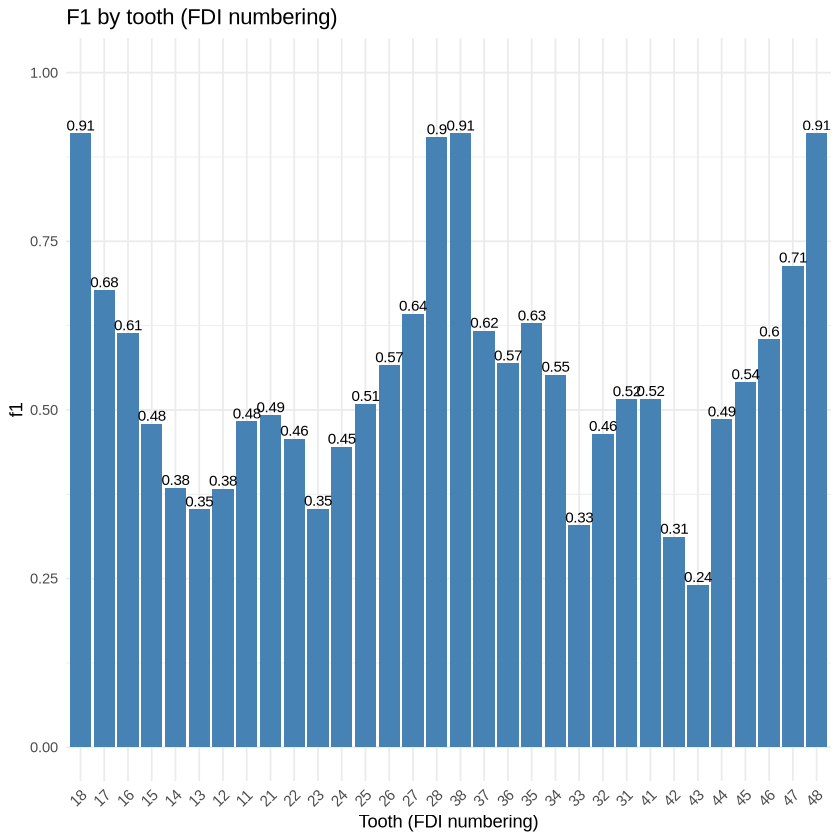

In [81]:
# Para F1-score de dentes ausentes
plot_metric_by_tooth(resultado_ausente, metric = "f1", color = "steelblue")

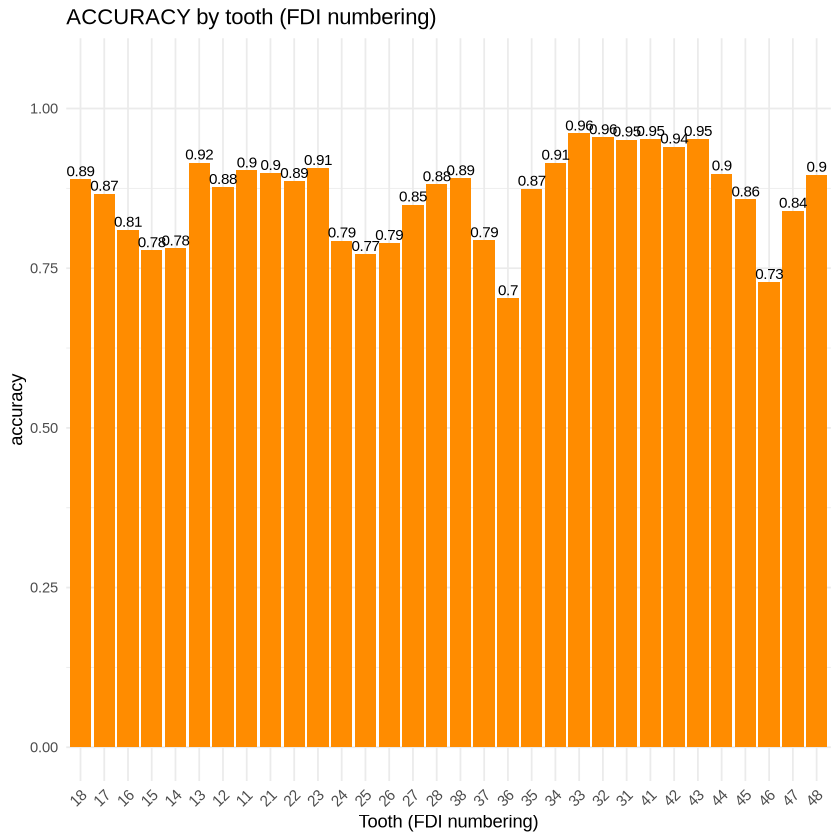

In [82]:
# Para acurácia de dentes ausentes
plot_metric_by_tooth(resultado_ausente, metric = "accuracy", color = "darkorange")

In [83]:
resumo_ausente <- aggregate_macro_micro(resultado_ausente)

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision recall    f1 accuracy
  <chr>     <dbl>  <dbl> <dbl>    <dbl>
1 macro     0.600  0.532 0.549    0.866
2 micro     0.734  0.630 0.678    0.866
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


#### Considerando somente a quantidade absoluta de dentes ausentes por indivíduo

In [84]:
resultado_ausente_count <- compute_counts_by_exam(gabarito, predicao, prefix = "ausente")
resultado_ausente_count

cd_exame,count_gt,count_pred,prefix,diff,abs_diff,correct_count
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>
alp.026080,0,0,ausente,0,0,1
alp.026233,1,1,ausente,0,0,1
alp.026520,13,10,ausente,-3,3,0
alp.026854,0,0,ausente,0,0,1
alp.026933,1,10,ausente,9,9,0
alp.027497,12,9,ausente,-3,3,0
alp.027622,1,0,ausente,-1,1,0
alp.027806,3,3,ausente,0,0,1
alp.027880,5,4,ausente,-1,1,0


In [85]:
summarize_count_metrics(resultado_ausente_count)

prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ausente,2515,0.2548708,2.872763,4.732738,-1.015109


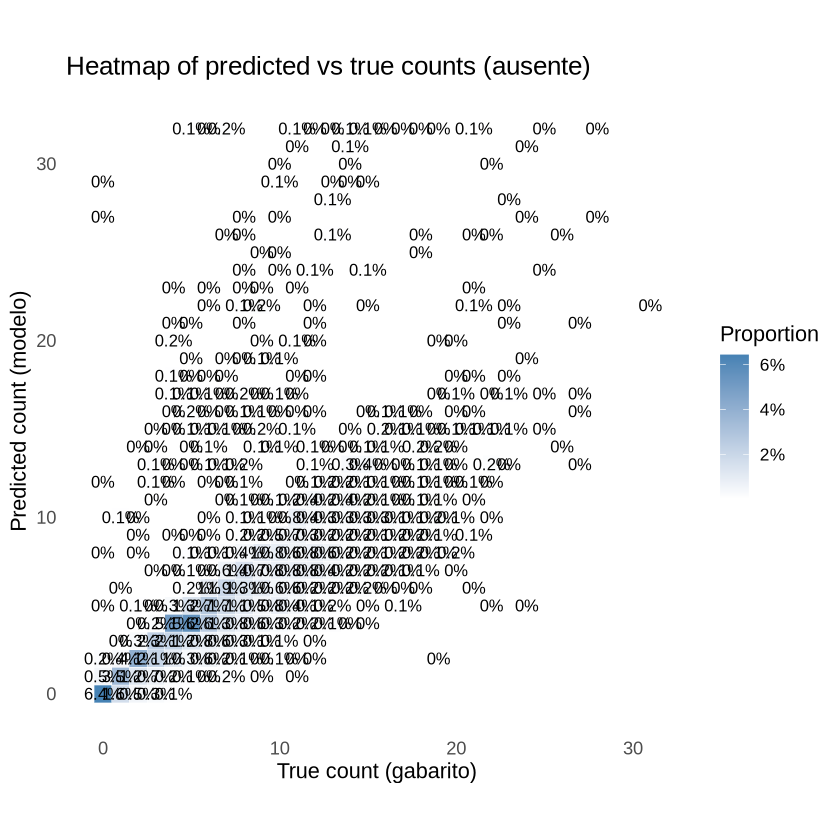

In [86]:
contingency_table_counts(resultado_ausente_count, normalize = TRUE)

In [87]:
# (Opcional) salvar resultados
# write_csv(contagens, "avaliacao_contagem_por_exame.csv")
# write_csv(metricas_count, "metricas_globais_contagem.csv")
# write_csv(tab_contagem, "tabela_contingencia_contagens.csv")
# write_csv(acc_por_alvo, "exatidao_por_alvo_contagens.csv")

### Desempenho do modelo de cáries

In [88]:
resultado_carie  <- metrics_by_tooth(gabarito, predicao, prefix = "carie")
resultado_carie

target,coluna,dente,n,tp,fp,tn,fn,precision,recall,f1,accuracy,prevalence_gt,mean_count_gt,mean_count_pred
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
carie,carie_11,11,2515,0,0,2357,158,NA,0.000000000,NA,0.9371769,0.06282306,0.06282306,0.0000000000
carie,carie_12,12,2515,0,0,2318,197,NA,0.000000000,NA,0.9216700,0.07833002,0.07833002,0.0000000000
carie,carie_13,13,2515,0,0,2345,170,NA,0.000000000,NA,0.9324056,0.06759443,0.06759443,0.0000000000
carie,carie_14,14,2515,0,0,2326,189,NA,0.000000000,NA,0.9248509,0.07514911,0.07514911,0.0000000000
carie,carie_15,15,2515,0,3,2261,251,0.0000000,0.000000000,NA,0.8990060,0.09980119,0.09980119,0.0011928429
carie,carie_16,16,2515,2,1,2178,334,0.6666667,0.005952381,0.011799410,0.8667992,0.13359841,0.13359841,0.0011928429
carie,carie_17,17,2515,1,3,2252,259,0.2500000,0.003846154,0.007575758,0.8958250,0.10337972,0.10337972,0.0015904573
carie,carie_18,18,2515,0,1,2410,104,0.0000000,0.000000000,NA,0.9582505,0.04135189,0.04135189,0.0003976143
carie,carie_21,21,2515,0,0,2363,152,NA,0.000000000,NA,0.9395626,0.06043738,0.06043738,0.0000000000


Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`geom_text()`).”


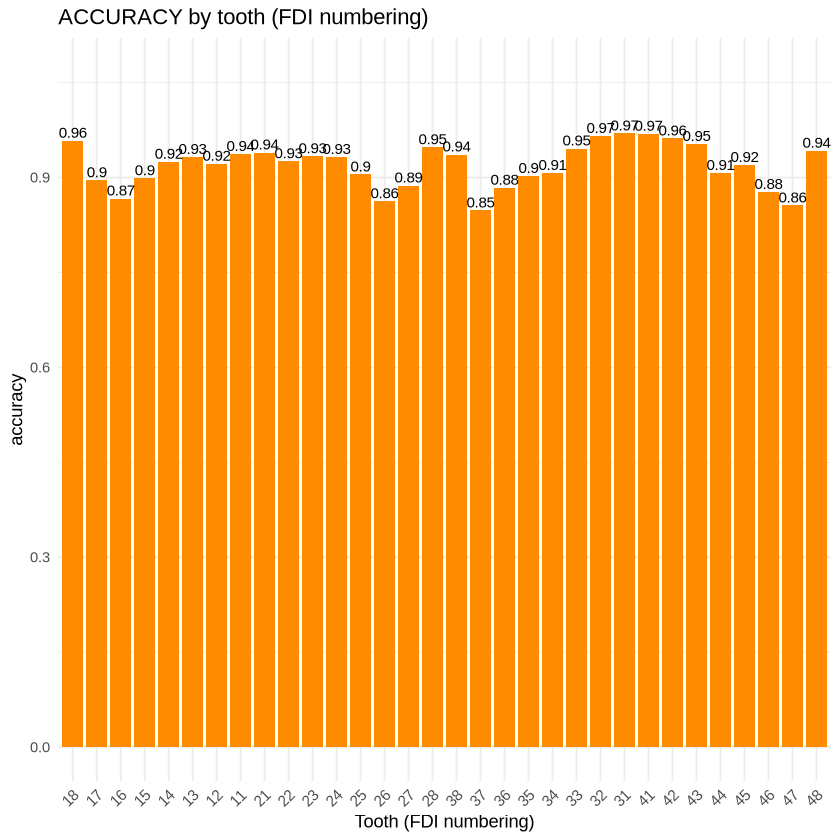

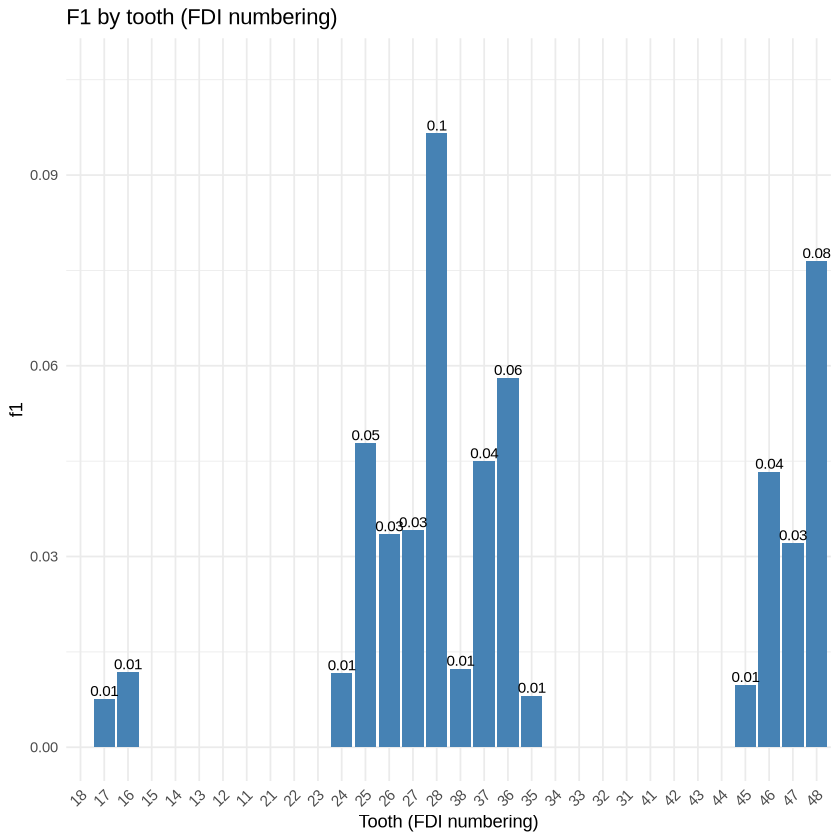

In [89]:
plot_metric_by_tooth(resultado_carie, metric = "accuracy", color = "darkorange")
plot_metric_by_tooth(resultado_carie, metric = "f1", color = "steelblue")

In [90]:
resumo_carie <- aggregate_macro_micro(resultado_carie)

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision  recall     f1 accuracy
  <chr>     <dbl>   <dbl>  <dbl>    <dbl>
1 macro     0.476 0.00863 0.0352    0.919
2 micro     0.504 0.0105  0.0205    0.919
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


#### Considerando somente a quantidade absoluta de cariados por indivíduo

In [91]:
resultado_carie_count = compute_counts_by_exam(gabarito, predicao, prefix = "carie")

prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
carie,2515,0.2751491,2.535189,3.739638,-2.528827


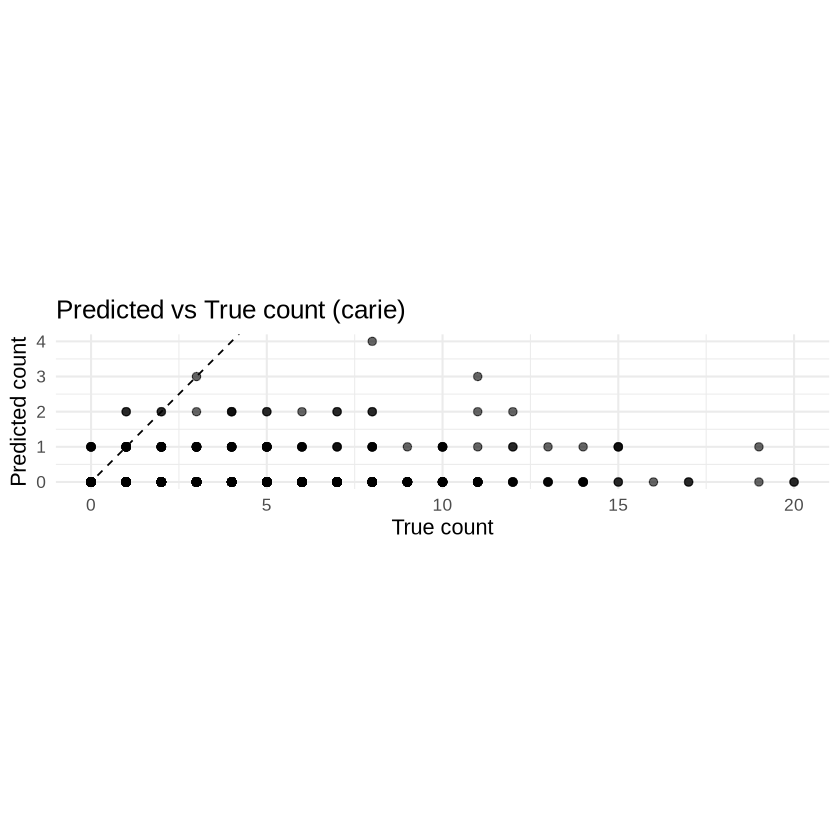

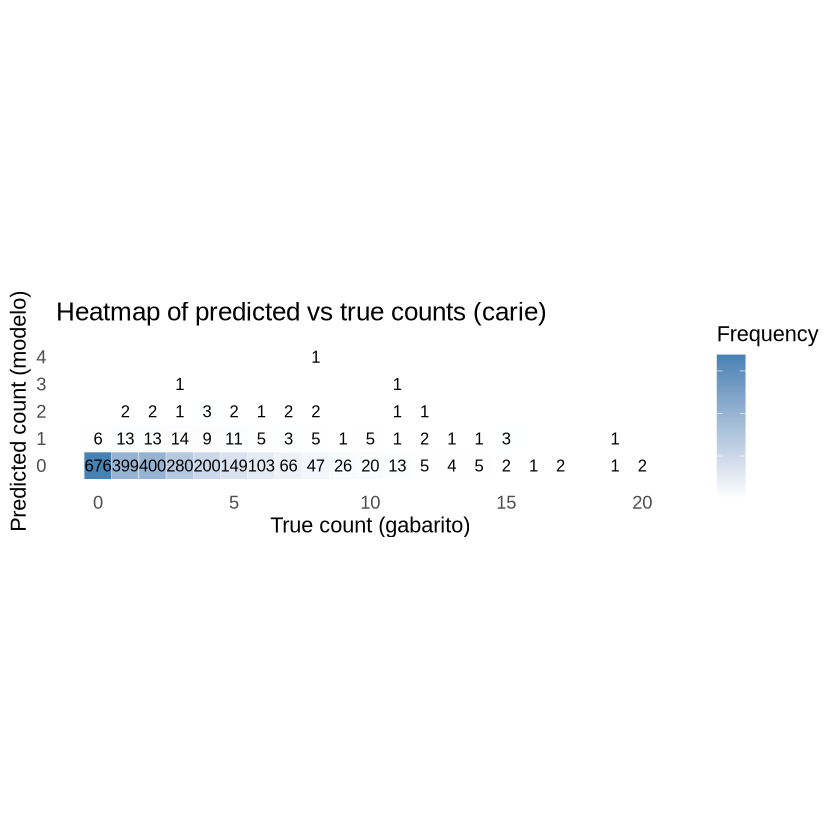

In [92]:
summarize_count_metrics(resultado_carie_count)
plot_counts_scatter(resultado_carie_count)
contingency_table_counts(resultado_carie_count)

### Desempenho do modelo de obturados

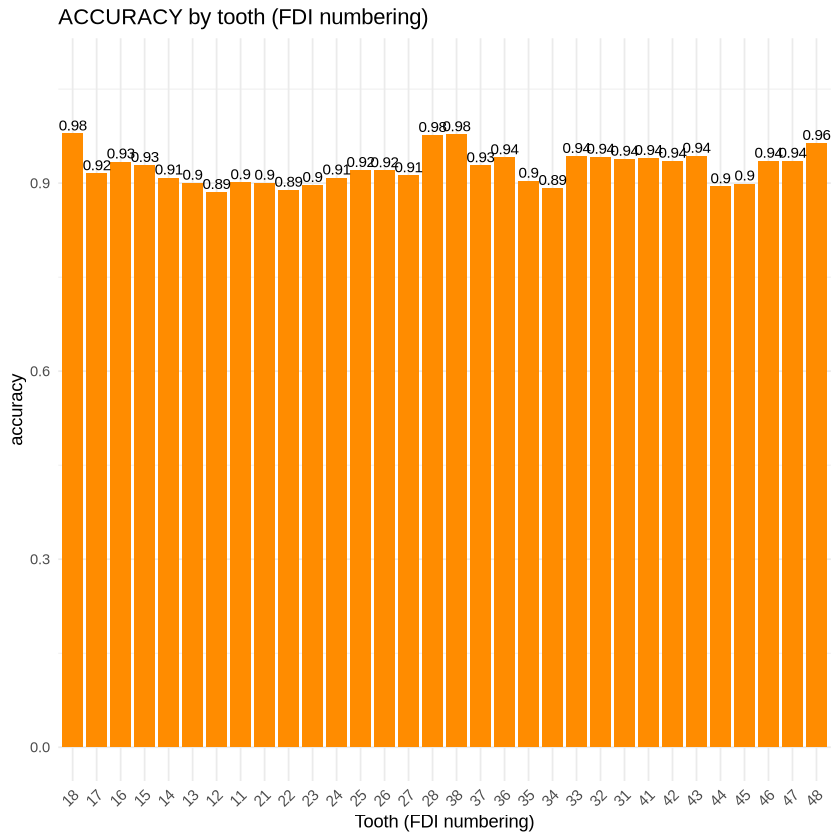

[1] "Resumo global (macro e micro):"
# A tibble: 2 × 6
  agg   precision recall    f1 accuracy
  <chr>     <dbl>  <dbl> <dbl>    <dbl>
1 macro     0.970  0.762 0.848    0.925
2 micro     0.976  0.800 0.879    0.925
  description                                                                  
  <chr>                                                                        
1 Average of metrics across all teeth (each tooth has equal weight)            
2 Global metrics considering all teeth together (weighted by number of samples)


prefix,n_exames,exact_match_rate,mae,rmse,bias
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
obturado,2515,0.1296223,3.347913,4.529383,-3.156262


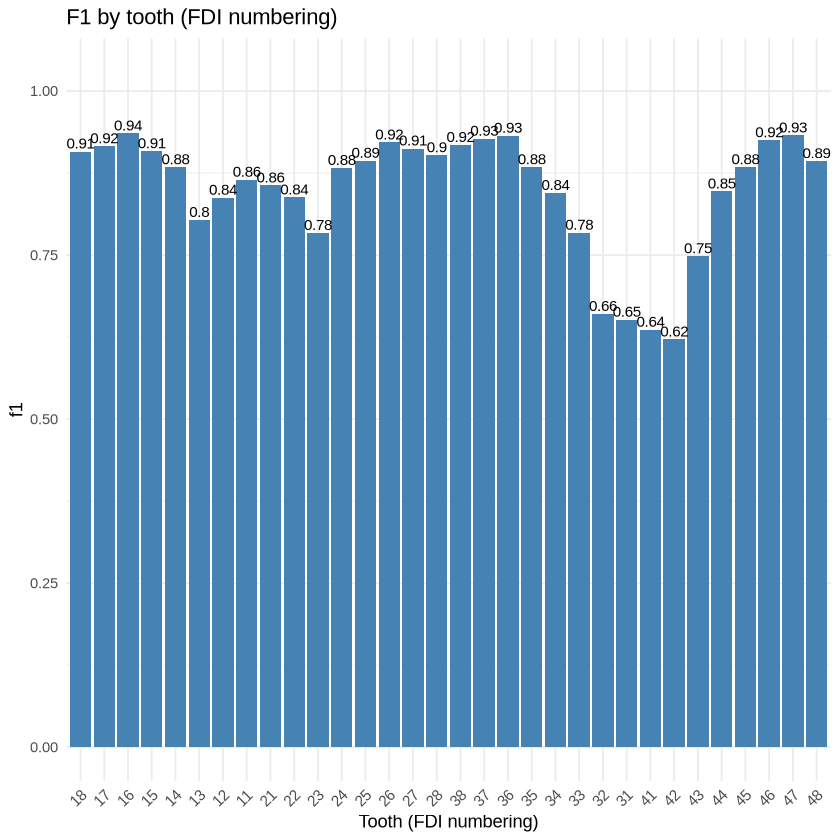

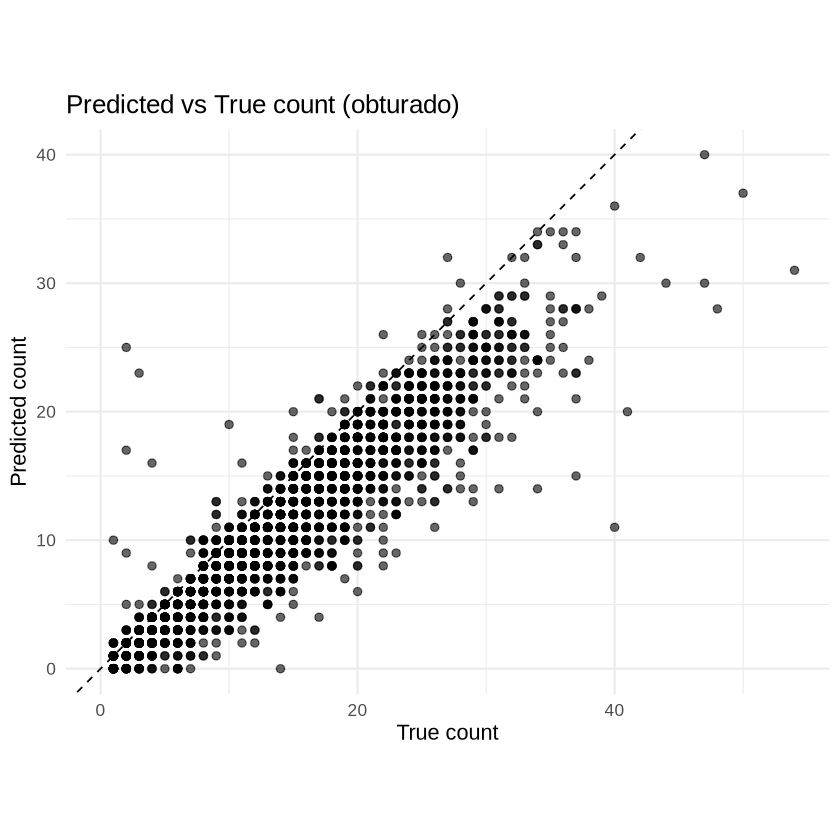

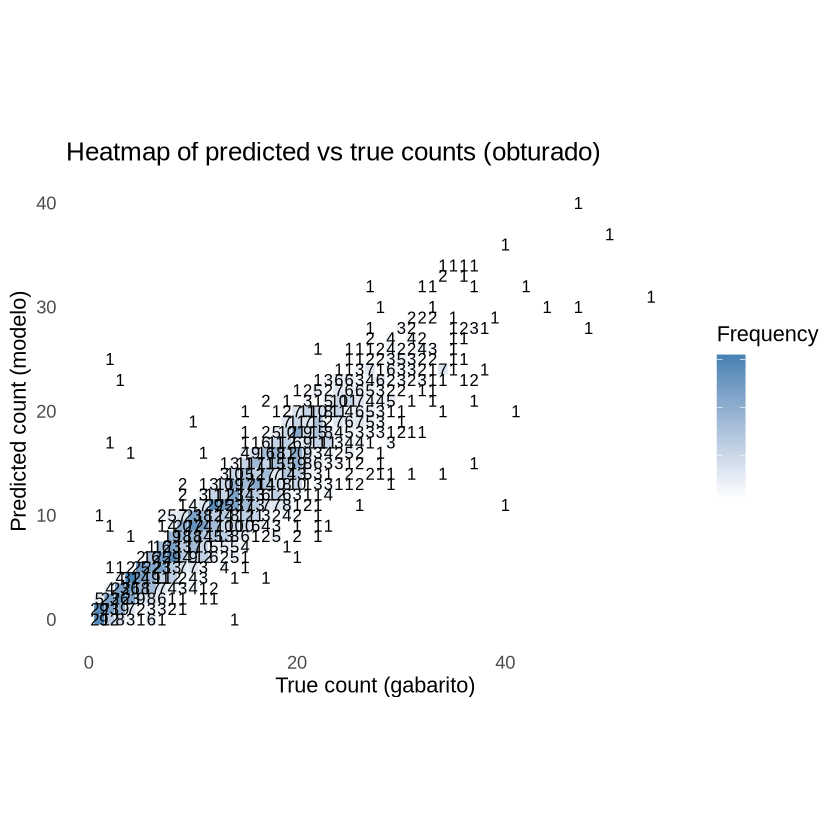

In [93]:
resultado_obturado  <- metrics_by_tooth(gabarito, predicao, prefix = "obturado")
plot_metric_by_tooth(resultado_obturado, metric = "accuracy", color = "darkorange")
plot_metric_by_tooth(resultado_obturado, metric = "f1", color = "steelblue")
resumo_obturado <- aggregate_macro_micro(resultado_obturado)
resultado_obturado_count = compute_counts_by_exam(gabarito, predicao, prefix = "obturado")
summarize_count_metrics(resultado_obturado_count)
plot_counts_scatter(resultado_obturado_count)
contingency_table_counts(resultado_obturado_count)

### CPOD - Gabarito

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0       14         3         17
2 alp.026233        1        4        17         22
3 alp.026520       13        6        23         42
4 alp.026854        0        2        10         12
5 alp.026933        1        3        10         14
6 alp.027497       12        0        18         30
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00   16.00   25.00   24.41   32.00   66.00 


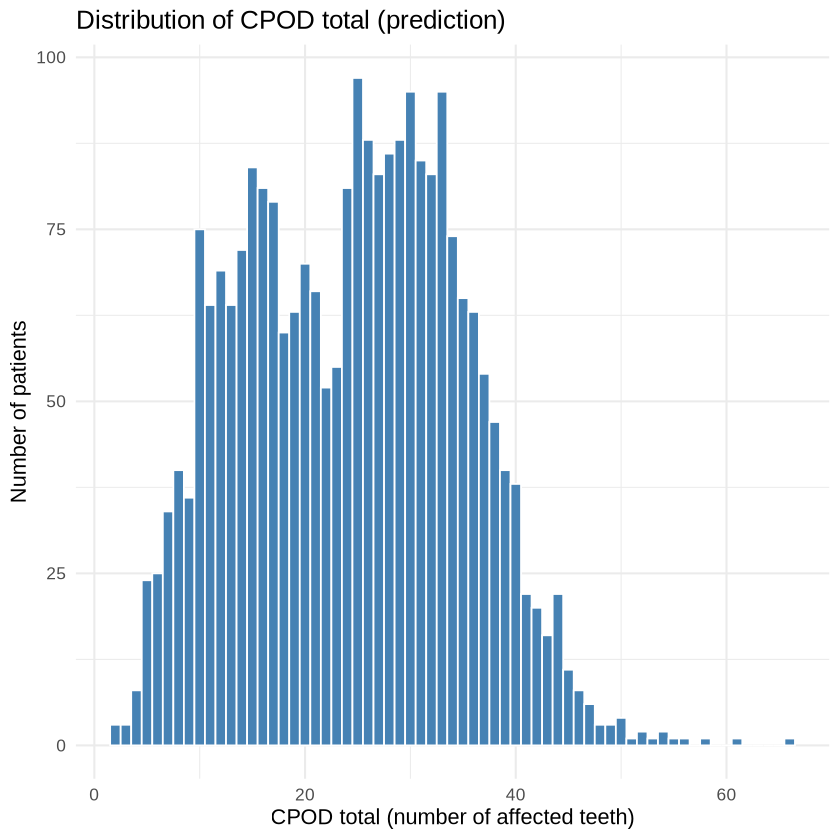

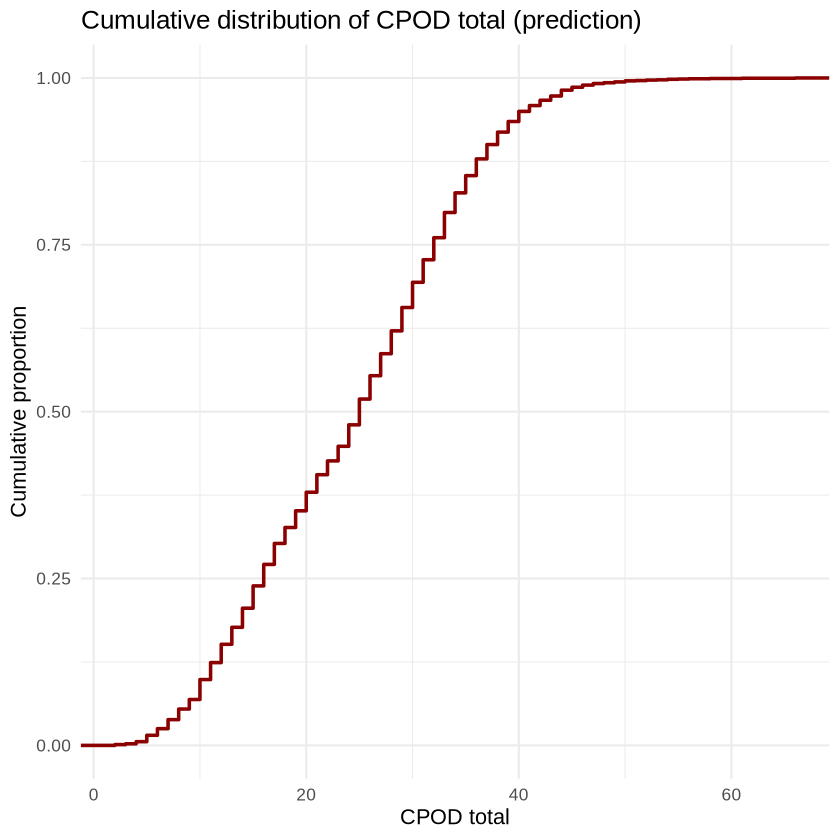

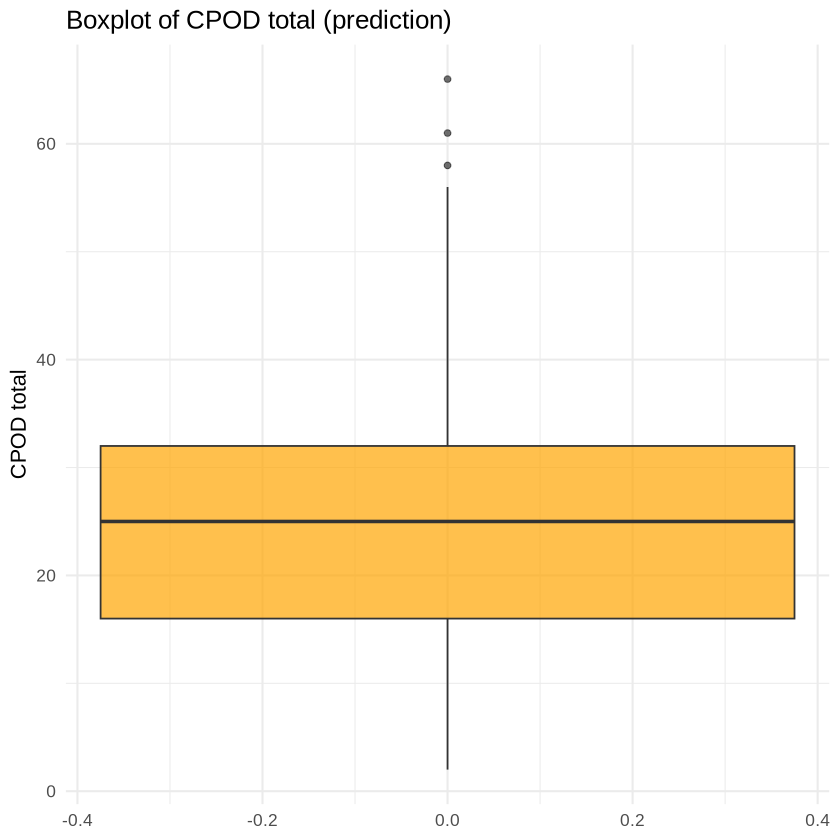

In [94]:
gabarito_cpod = analyze_cpod(gabarito, compute_cpod)

### CPOD - Predição

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0        1         3          4
2 alp.026233        1        0        14         15
3 alp.026520       10        0        12         22
4 alp.026854        0        1         7          8
5 alp.026933       10        0         3         13
6 alp.027497        9        0        17         26
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   11.00   18.00   17.71   24.00   58.00 


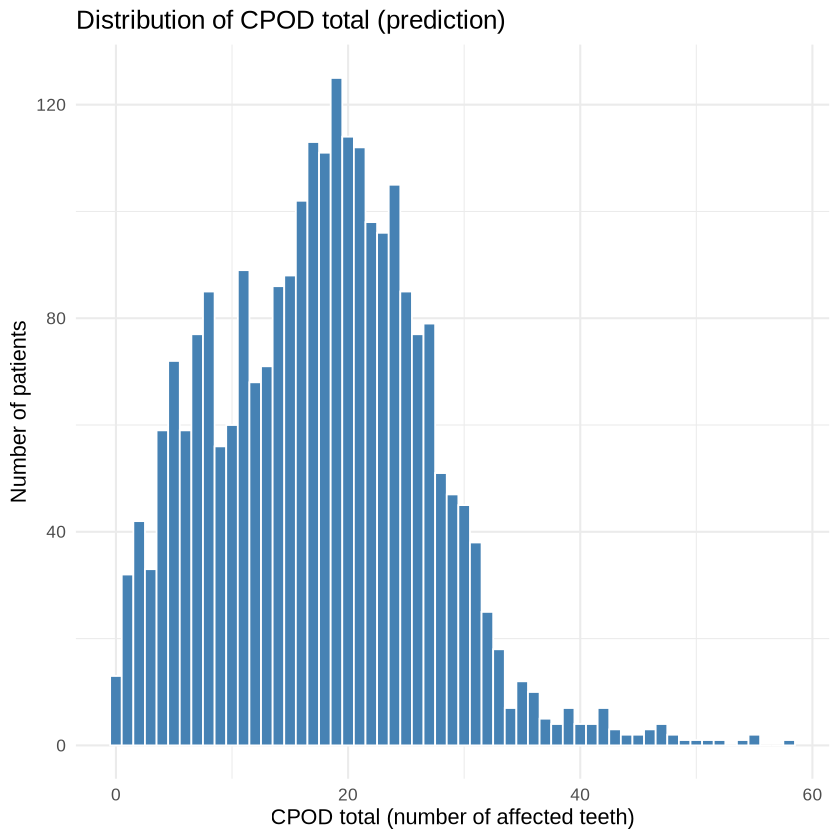

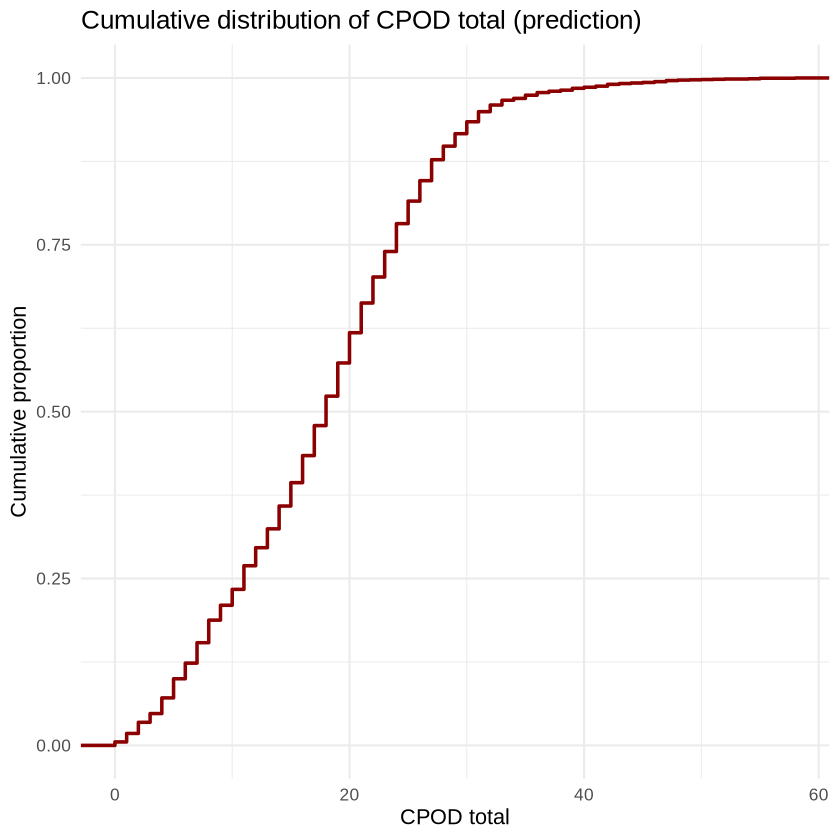

cd_exame,ausentes,cariados,obturados,cpod_total
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
alp.026080,0,1,3,4
alp.026233,1,0,14,15
alp.026520,10,0,12,22
alp.026854,0,1,7,8
alp.026933,10,0,3,13
alp.027497,9,0,17,26


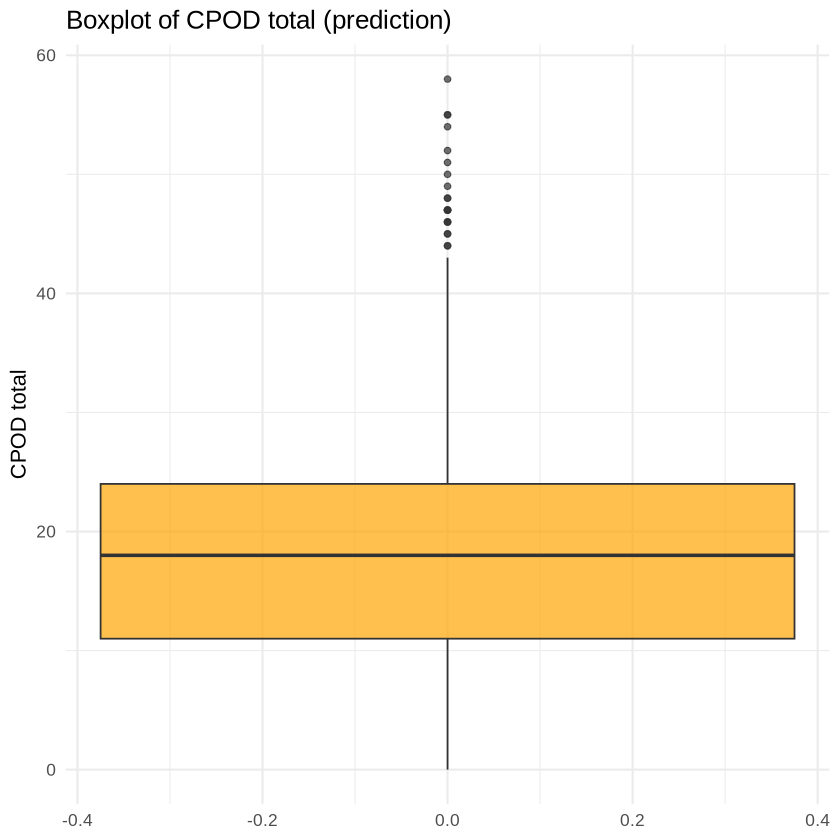

In [95]:
predicao_cpod = analyze_cpod(predicao, compute_cpod)
head(predicao_cpod)

### CPOD - Comparação

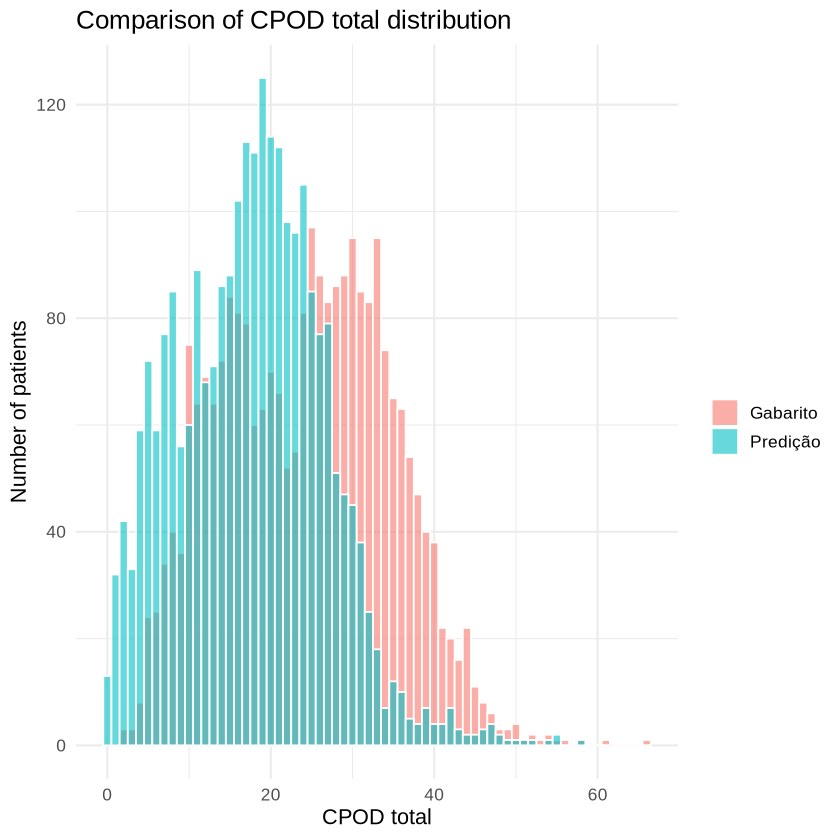

In [96]:
bind_rows(
  gabarito_cpod %>% mutate(tipo = "Gabarito"),
  predicao_cpod %>% mutate(tipo = "Predição")
) %>%
  ggplot(aes(x = cpod_total, fill = tipo)) +
  geom_histogram(binwidth = 1, position = "identity", alpha = 0.6, color = "white") +
  labs(
    title = "Comparison of CPOD total distribution",
    x = "CPOD total",
    y = "Number of patients",
    fill = ""
  ) +
  theme_minimal(base_size = 13)


### CPOD (binário) - Gabarito

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0       14         3         17
2 alp.026233        1        4        13         18
3 alp.026520       13        6        14         33
4 alp.026854        0        2         7          9
5 alp.026933        1        3         3          7
6 alp.027497       12        0        14         26
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00   14.00   22.00   20.69   27.00   47.00 


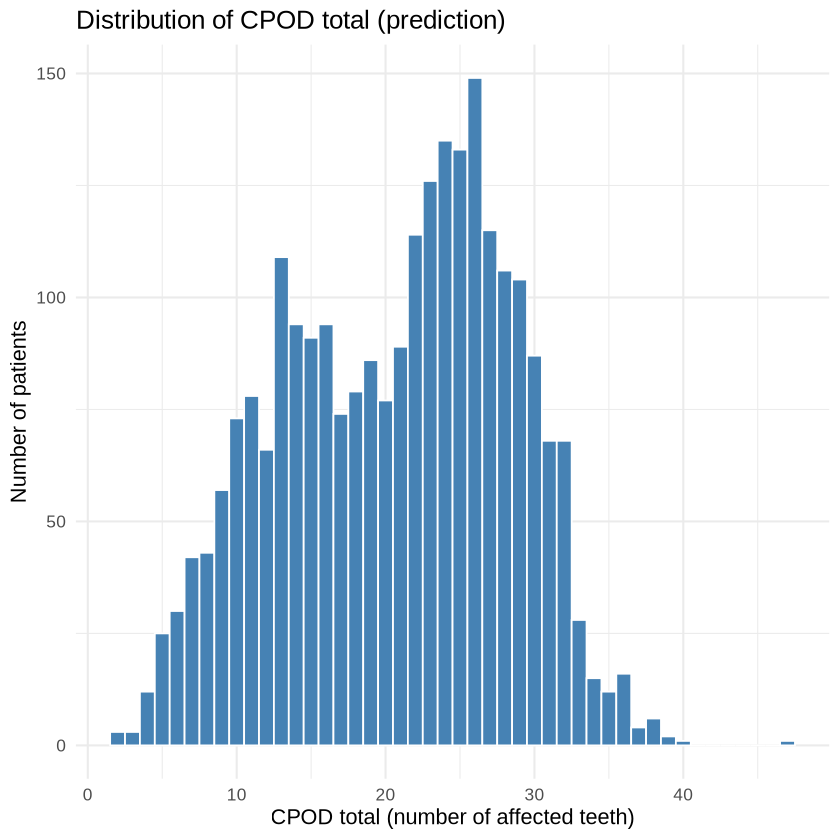

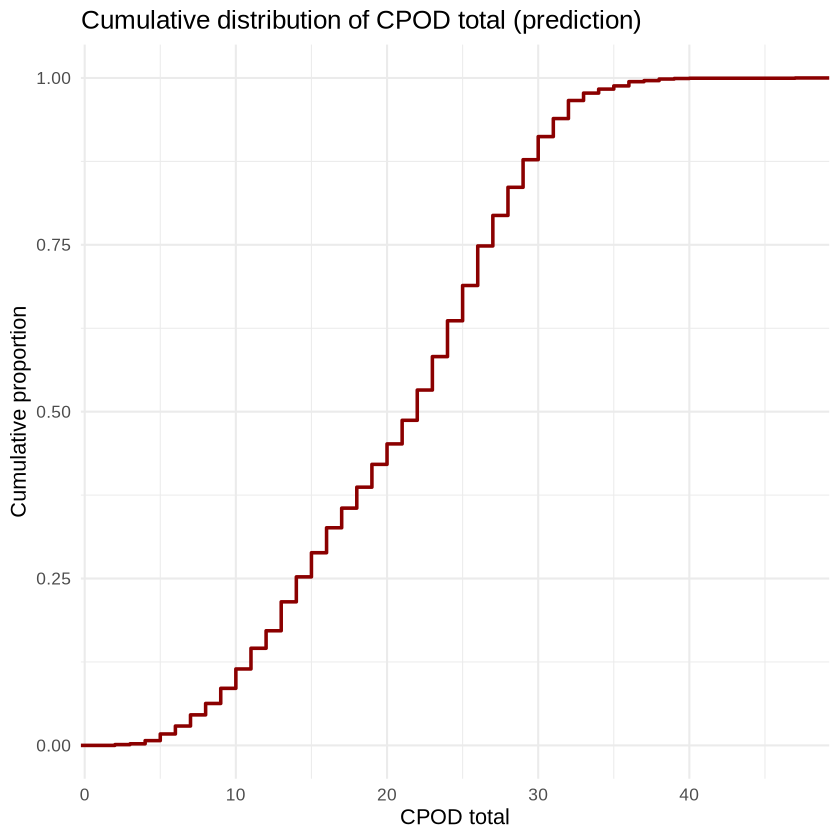

cd_exame,ausentes,cariados,obturados,cpod_total
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
alp.026080,0,14,3,17
alp.026233,1,4,13,18
alp.026520,13,6,14,33
alp.026854,0,2,7,9
alp.026933,1,3,3,7
alp.027497,12,0,14,26


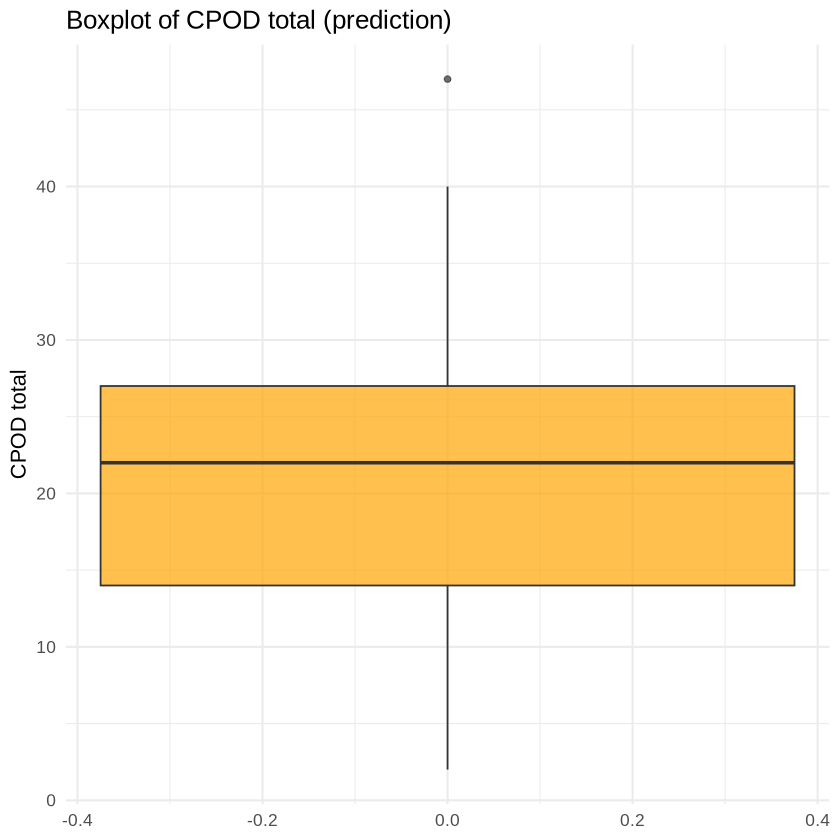

In [97]:
gabarito_cpod_bin = analyze_cpod(gabarito, compute_cpod_binaria)
head(gabarito_cpod_bin)

[1] "AIC comparison (lower = better):"
# A tibble: 3 × 3
  Model             LogLik    AIC
  <chr>              <dbl>  <dbl>
1 Normal            -8679. 17361.
2 Negative Binomial -8771. 17547.
3 Poisson           -9874. 19750.
[1] "Shapiro-Wilk p-value for normality: 0"


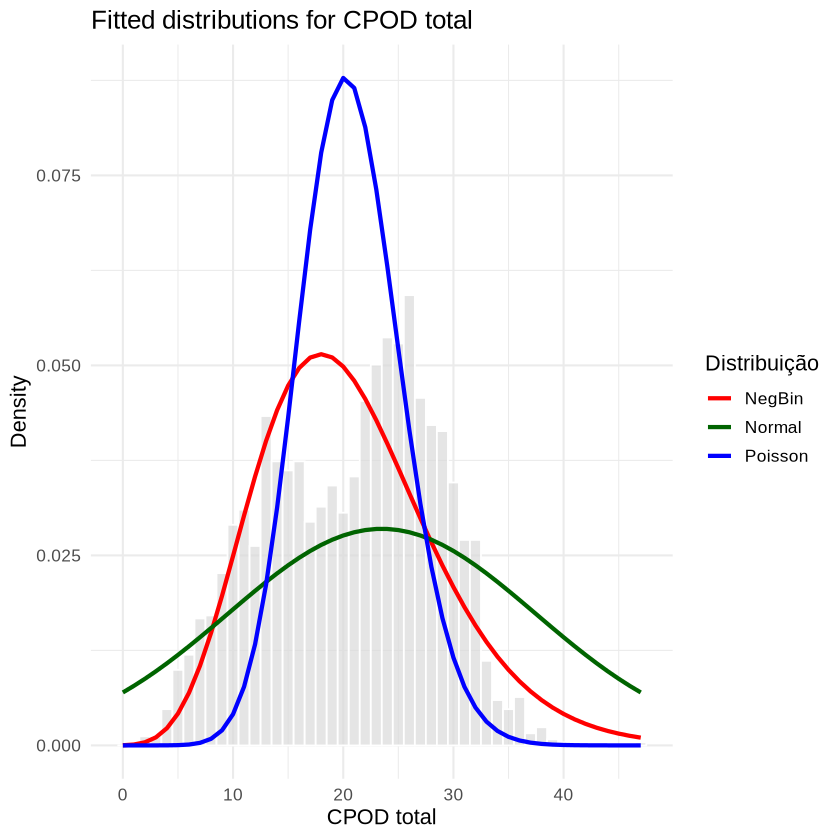

In [100]:
teste_dist_gabarito = test_cpod_distribution(gabarito_cpod_bin)

### CPOD (Binário) - Predição

# A tibble: 6 × 5
  cd_exame   ausentes cariados obturados cpod_total
  <chr>         <dbl>    <dbl>     <dbl>      <dbl>
1 alp.026080        0        1         3          4
2 alp.026233        1        0        10         11
3 alp.026520       10        0        11         21
4 alp.026854        0        1         5          6
5 alp.026933       10        0         2         12
6 alp.027497        9        0        11         20
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   10.00   16.00   15.16   20.00   49.00 


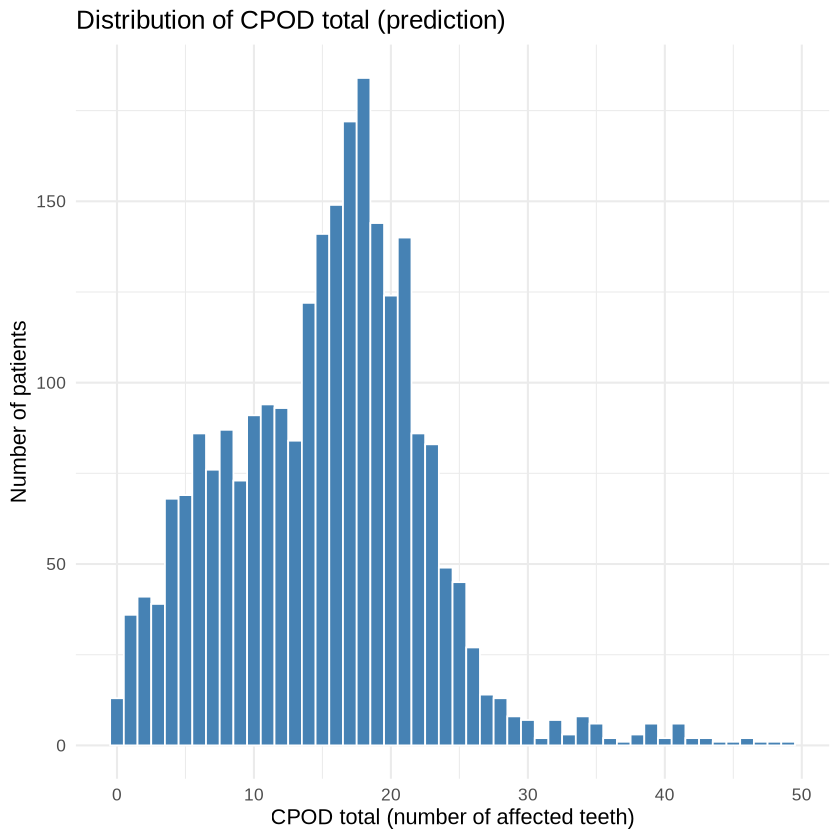

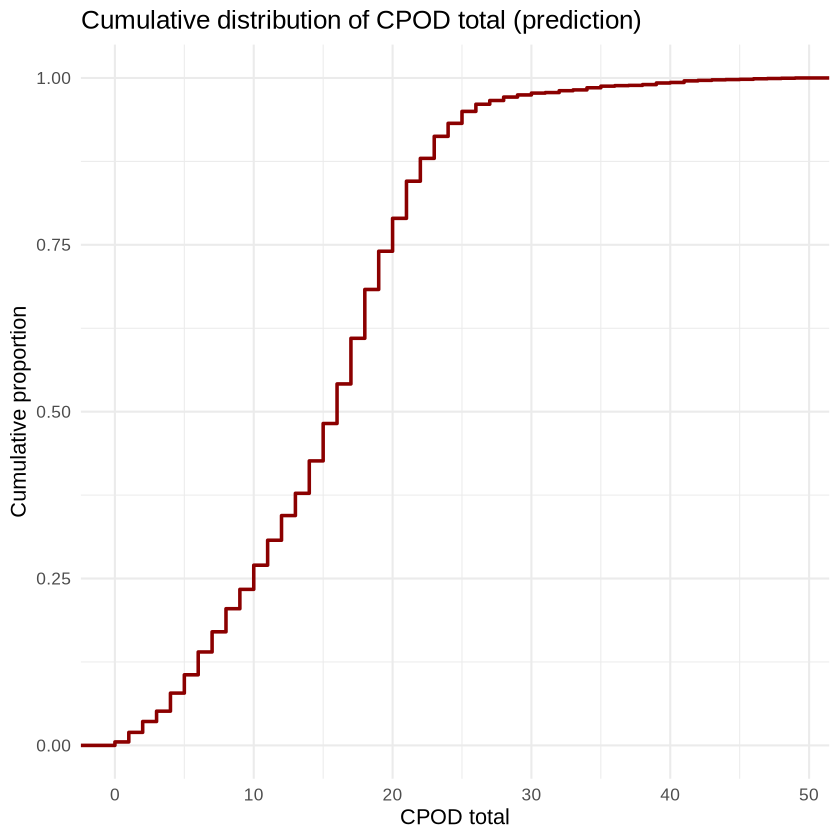

cd_exame,ausentes,cariados,obturados,cpod_total
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
alp.026080,0,1,3,4
alp.026233,1,0,10,11
alp.026520,10,0,11,21
alp.026854,0,1,5,6
alp.026933,10,0,2,12
alp.027497,9,0,11,20


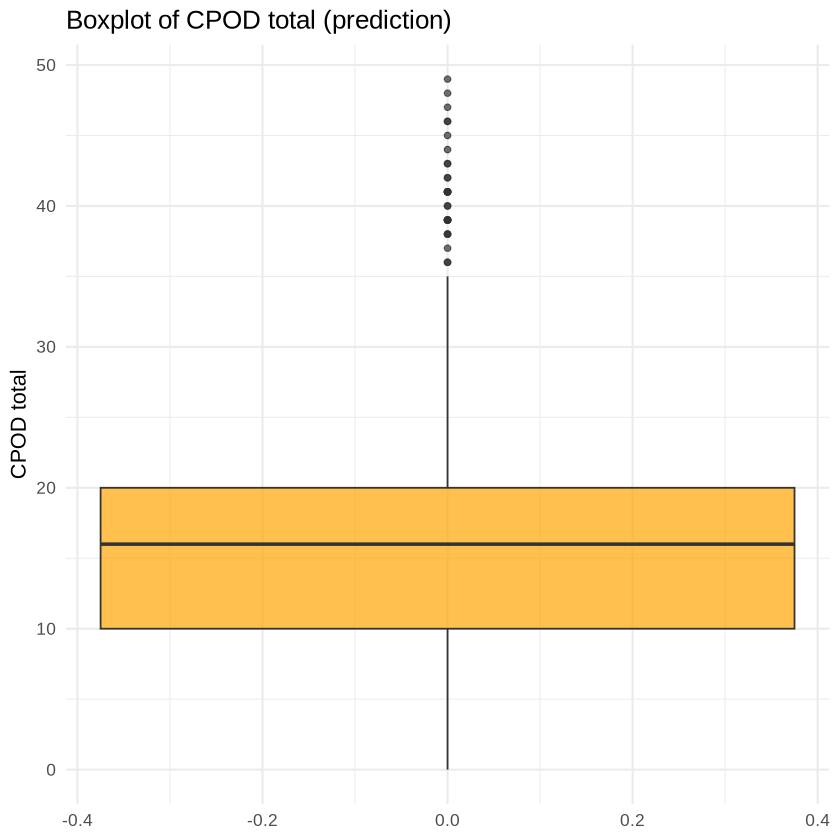

In [102]:
predicao_cpod_bin = analyze_cpod(predicao, compute_cpod_binaria)
head(predicao_cpod_bin)

[1] "AIC comparison (lower = better):"
# A tibble: 3 × 3
  Model              LogLik    AIC
  <chr>               <dbl>  <dbl>
1 Normal             -8562. 17129.
2 Negative Binomial  -8618. 17240.
3 Poisson           -10328. 20657.
[1] "Shapiro-Wilk p-value for normality: 0"


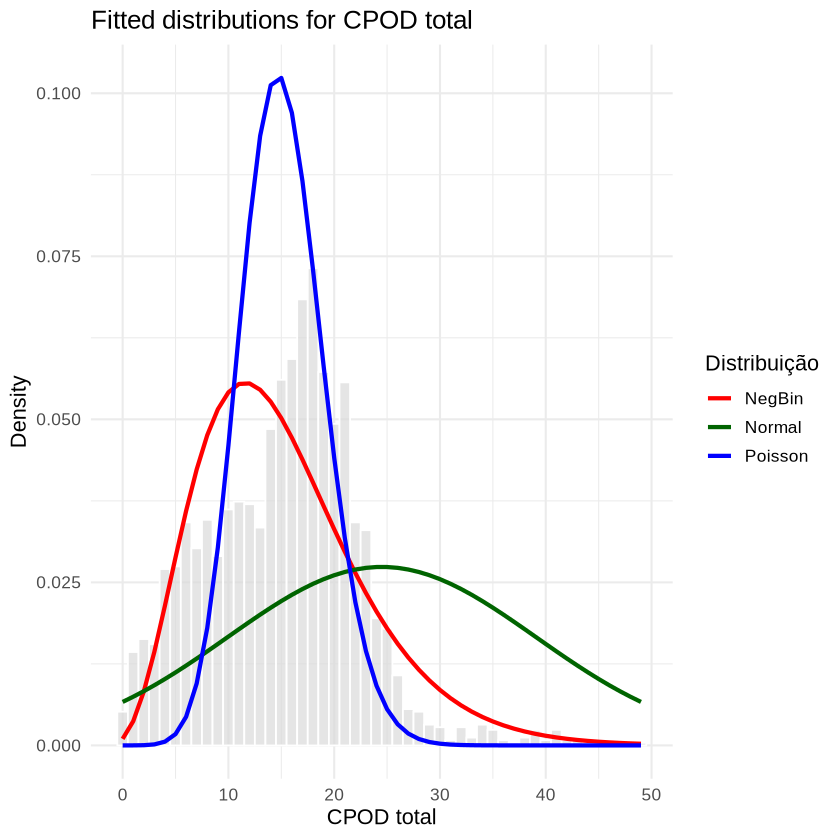

In [103]:
teste_dist_predicao = test_cpod_distribution(predicao_cpod_bin)

### CPOD (binário) - Comparação

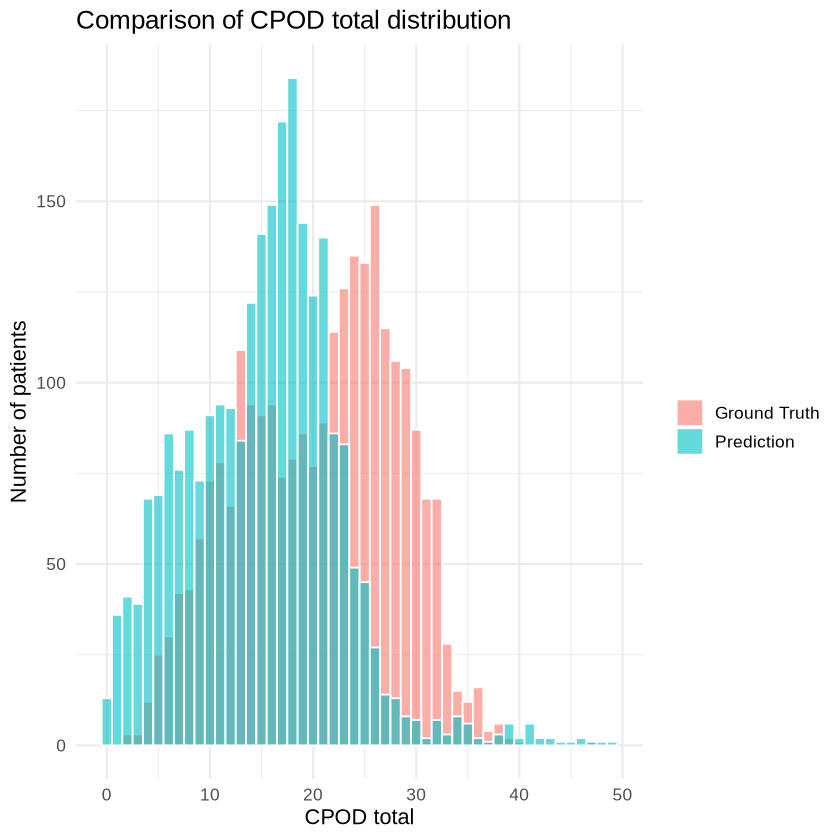

In [104]:
bind_rows(
  gabarito_cpod_bin %>% mutate(tipo = "Ground Truth"),
  predicao_cpod_bin %>% mutate(tipo = "Prediction")
) %>%
  ggplot(aes(x = cpod_total, fill = tipo)) +
  geom_histogram(binwidth = 1, position = "identity", alpha = 0.6, color = "white") +
  labs(
    title = "Comparison of CPOD total distribution",
    x = "CPOD total",
    y = "Number of patients",
    fill = ""
  ) +
  theme_minimal(base_size = 13)